In [1]:
from pathlib import Path
from qqe.GNN.training.datasets import build_loaders, build_loaders_NN

In [2]:
def collect_files_path(
    data_dir: str,
    family: str | None = None,
    backend: str | None = "pennylane",
    target: str | None = "sre",
) -> list[str]:
    """Collects file paths matching the pattern in the given directory."""
    d = Path(data_dir)
    if family is not None:
        paths = sorted((d / f"encoding_data_{target}_{backend}" / family).glob("*.pt"))
    else:
        paths = []
        encoding_dir = d / f"encoding_data_{target}_{backend}"
        if encoding_dir.exists():
            for family_dir in sorted(encoding_dir.iterdir()):
                if family_dir.is_dir():
                    paths.extend(sorted(family_dir.glob("*.pt")))
    if not paths:
        paths = sorted(d.glob("*.pt"))
    return [str(p) for p in paths]

In [20]:
family_filter = "clifford"

data_paths = collect_files_path("../data/training_data", family=family_filter)
if not data_paths:
    raise RuntimeError("No data paths found.")

print(f"Found {len(data_paths)} data paths.")

Found 35000 data paths.


In [21]:
train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = (
    build_loaders(
        data_paths,
        batch_size=50,
        seed=24,
        train_split=0.8,
        val_split=0.15,
        global_feature_variant="binned",
        node_feature_variant=None,
        family_projection=family_filter,
    )
)

In [22]:
print(len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

23800 4200 7000


In [23]:
training_data = train_loader.dataset
validation_data = val_loader.dataset
test_data = test_loader.dataset

In [24]:
from collections import Counter

def count_regimes(dataset):
    return Counter(data.meta["regime"] for data in dataset)



In [25]:
train_counts = count_regimes(training_data)
val_counts   = count_regimes(validation_data)
test_counts  = count_regimes(test_data)

print("Train:", train_counts)
print("Val:", val_counts)
print("Test:", test_counts)

Train: Counter({'low': 8179, 'medium': 7276, 'high': 4771, 'zero': 3574})
Val: Counter({'low': 1486, 'medium': 1242, 'high': 833, 'zero': 639})
Test: Counter({'low': 2428, 'medium': 2124, 'high': 1384, 'zero': 1064})


In [26]:
import pandas as pd

def regime_table(train_dataset, val_dataset, test_dataset):
    train = count_regimes(train_dataset)
    val   = count_regimes(val_dataset)
    test  = count_regimes(test_dataset)

    df = pd.DataFrame([train, val, test], index=["train", "val", "test"])
    return df.fillna(0).astype(int)

df_regimes = regime_table(training_data, validation_data, test_data)
print(df_regimes)

        low  high  medium  zero
train  8179  4771    7276  3574
val    1486   833    1242   639
test   2428  1384    2124  1064


In [27]:
df_regimes.div(df_regimes.sum(axis=1), axis=0)

,low,high,medium,zero
train,0.343655,0.200462,0.305714,0.150168
val,0.353810,0.198333,0.295714,0.152143
test,0.346857,0.197714,0.303429,0.152000


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
res_gnn_random = pd.read_csv("../../outputs/predictions/family/gnn_predictions_random.csv")

In [ ]:
print(res_gnn_random)

                               cid  family        seed  n_qubits  n_layers  \
0      random_Q12_L100_S1011422080  random  1011422080        12       100   
1      random_Q12_L100_S1035782221  random  1035782221        12       100   
2       random_Q12_L100_S106832620  random   106832620        12       100   
3      random_Q12_L100_S1081084085  random  1081084085        12       100   
4      random_Q12_L100_S1111761447  random  1111761447        12       100   
...                            ...     ...         ...       ...       ...   
38245    random_Q30_L98_S918214833  random   918214833        30        98   
38246     random_Q30_L98_S93458835  random    93458835        30        98   
38247    random_Q30_L98_S960935828  random   960935828        30        98   
38248    random_Q30_L98_S962473666  random   962473666        30        98   
38249    random_Q30_L98_S978151905  random   978151905        30        98   

       target  prediction  error  
0         NaN    9.946802   

In [5]:
nq = 10
nl = 10

subset = res_gnn_random[(res_gnn_random["n_qubits"] == nq) & (res_gnn_random["n_layers"] == nl)].copy()

# Reset index so "sample index" is clean
subset = subset.reset_index(drop=True)

In [6]:
print(subset.head())

Empty DataFrame
Columns: [cid, family, seed, n_qubits, n_layers, target, prediction, error]
Index: []


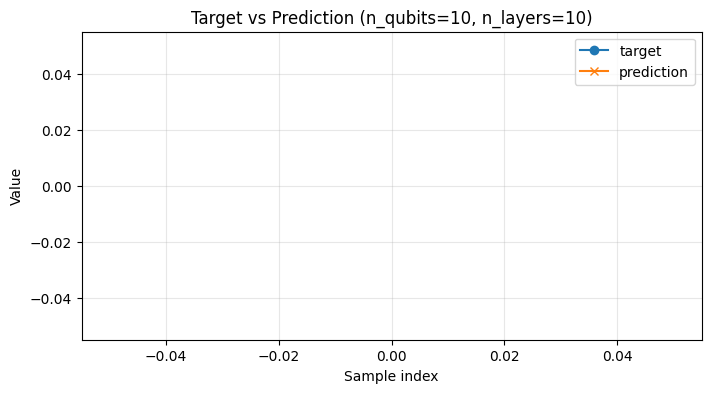

In [7]:
plt.figure(figsize=(8, 4))

x = subset.index  # sample index (what you want)

plt.plot(x, subset["target"], label="target", marker="o")
plt.plot(x, subset["prediction"], label="prediction", marker="x")

plt.xlabel("Sample index")
plt.ylabel("Value")
plt.title(f"Target vs Prediction (n_qubits={nq}, n_layers={nl})")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [8]:

import numpy as np


def pearson_corr_fast(df: pd.DataFrame, col_x: str, col_y: str) -> float:
    x = df[col_x].to_numpy(dtype=float)
    y = df[col_y].to_numpy(dtype=float)
    return float(np.corrcoef(x, y)[0, 1])

In [9]:
r = pearson_corr_fast(subset, "target", "prediction")
print(f"Pearson r = {r:.4f}")

Pearson r = nan


c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in m

In [10]:
def view_correlation(
    df: pd.DataFrame,
    nq: int = 10,
    nl: int = 100,
    col_x: str = "target",
    col_y: str = "prediction",
):


    subset = df[(df["n_qubits"] == nq) & (df["n_layers"] == nl)].copy()

    # Reset index so "sample index" is clean
    subset = subset.reset_index(drop=True)

    plt.figure(figsize=(8, 4))

    x = subset.index  # sample index (what you want)

    plt.plot(x, subset[col_x], label="target", marker="o")
    plt.plot(x, subset[col_y], label="prediction", marker="x")

    plt.xlabel("Sample index")
    plt.ylabel("Value")
    plt.title(f"Target vs Prediction (n_qubits={nq}, n_layers={nl})")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()
    r = pearson_corr_fast(subset, col_x, col_y)
    print(f"Pearson r = {r:.4f}")

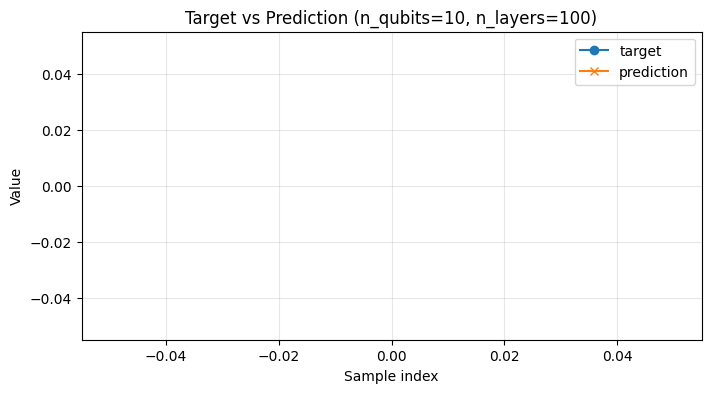

Pearson r = nan


c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in m

In [12]:
view_correlation(res_gnn_random, nq=10, nl=100, col_x="target", col_y="prediction")

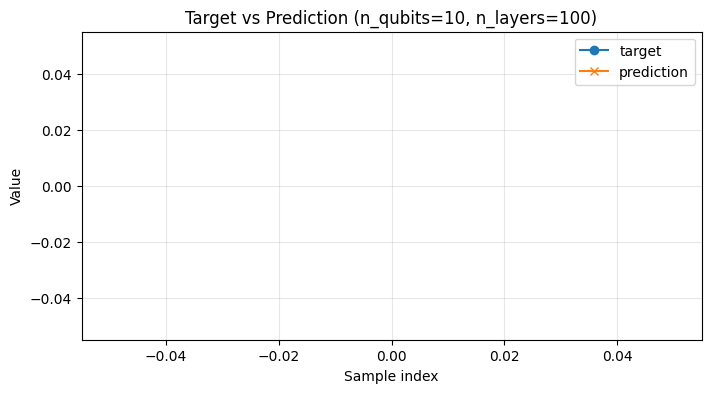

Pearson r = nan


c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in m

In [13]:
view_correlation(res_gnn_random, nq=10, nl=100, col_x="target", col_y="prediction")

In [14]:
import ast

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

In [15]:
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    res_gnn_random[col] = res_gnn_random[col].apply(to_scalar).astype(int)

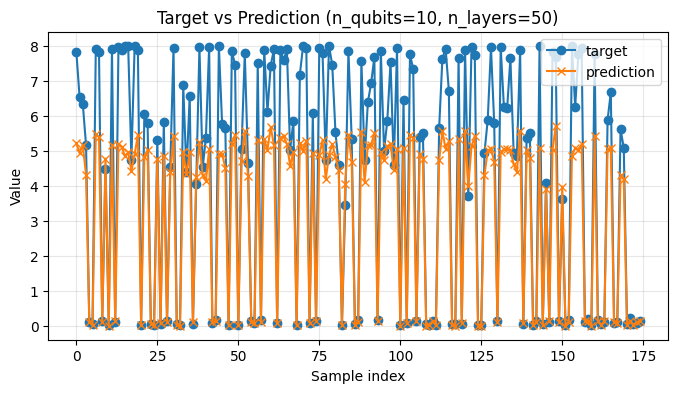

Pearson r = 0.9734


In [17]:
view_correlation(res_gnn_random, nq=10, nl=50, col_x="target", col_y="prediction")